<a href="https://colab.research.google.com/github/zelinsckiy/Python-for-DS-home-tasks/blob/main/Copy_of_1_2_%D0%9B%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Завантаження даних

Для початку, давайте завантажимо дані з файлу csv.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
!ls 'drive/MyDrive/ML Intensive from 0 to Hero'

ls: cannot access 'drive/MyDrive/ML Intensive from 0 to Hero': No such file or directory


In [4]:
file_name = 'drive/MyDrive/Colab Notebooks/medical-charges.csv'

In [5]:
medical_df = pd.read_csv(file_name)

## Лінійна регресія за допомогою однієї ознаки

Ми вже знаємо, що стовпці "курець" та "вік" мають найсильнішу кореляцію з "витратами". Спробуємо знайти спосіб оцінки значення "витрат" за допомогою значення "віку" для некурців. Спочатку створимо фрейм даних, який містить лише дані для некурців.

In [6]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

Далі, давайте візуалізуємо взаємозв'язок між "віком" та "витратами"

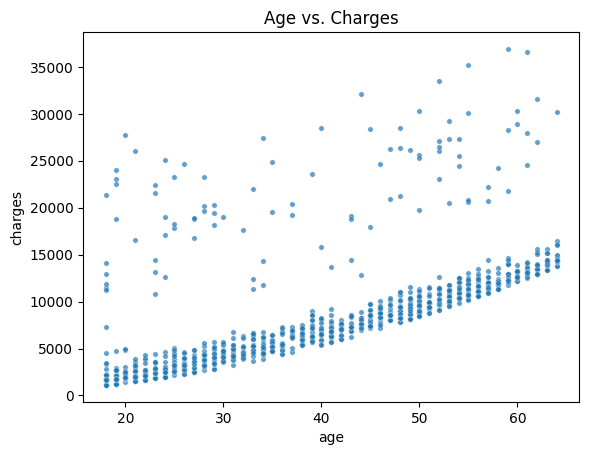

In [7]:
plt.title('Age vs. Charges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15);

Окрім декількох винятків, точки, здається, формують лінію. Ми спробуємо "підібрати" лінію, використовуючи ці точки, і використовувати лінію для прогнозування вартості за віком. Лінія на координатах X&Y має наступну формулу:

$y = wx + b$

Лінія характеризується двома числами: $w$ (називається "нахил") і $b$ (називається "зміщення").

### Модель

У вищенаведеному випадку вісь x показує `age`, а вісь y показує `charges`. Таким чином, ми припускаємо наступну залежність між ними:

$charges = w \times age + b$

Ми спробуємо визначити $w$ і $b$ для лінії, яка найкраще підходить для даних.

* Цей метод називається _лінійною регресією_, і ми називаємо вищенаведене рівняння _моделлю лінійної регресії_, оскільки воно моделює залежність між "віком" і "вартістю" як пряму лінію.

* Числа $w$ і $b$ називаються _параметрами_ або _вагами_ моделі.

* Значення в стовпці "вік" набору даних називаються _вхідними даними_ моделі, а значення в стовпці `charges` називаються "цільовими" (targets).

Давайте визначимо допоміжну функцію `estimate_charges`, щоб обчислити $charges$, з урахуванням $age$, $w$ і $b$.

In [8]:
def estimate_charges(age, w, b):
    return w * age + b

Функція `estimate_charges` є нашою першою _моделлю_.

Давайте _здогадаємося_ щодо значень для $w$ та $b$ і використаємо їх для оцінки вартості послуг.

In [9]:
w = 50
b = 100

In [10]:
ages = non_smoker_df.age
estimated_charges = estimate_charges(ages, w, b)

In [11]:
estimated_charges

,age
1,1000
2,1500
3,1750
4,1700
5,1650
...,...
1332,2700
1333,2600
1334,1000
1335,1000


Ми можемо відобразити оцінені витрати за допомогою лінійного графіка.

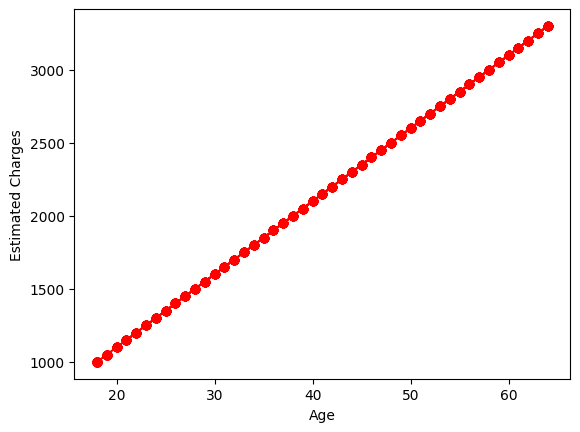

In [12]:
plt.plot(ages, estimated_charges, 'r-o');
plt.xlabel('Age');
plt.ylabel('Estimated Charges');

Як і очікувалося, точки лежать на прямій лінії.

Ми можемо накласти цю лінію на реальні дані, щоб побачити, наскільки добре наша _модель_ відповідає _даним_.

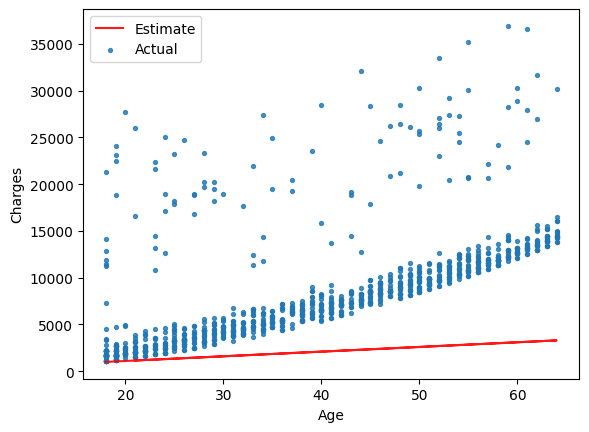

In [13]:
target = non_smoker_df.charges

plt.plot(ages, estimated_charges, 'r', alpha=0.9);
plt.scatter(ages, target, s=8, alpha=0.8);
plt.xlabel('Age');
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual']);

Очевидно, наші оцінки досить погані, і лінія не "підходить" до даних. Однак, ми можемо спробувати різні значення $w$ та $b$, щоб перемістити лінію. Давайте визначимо допоміжну функцію `try_parameters`, яка приймає `w` та `b` як вхідні дані та створює вищезазначений графік.

In [14]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

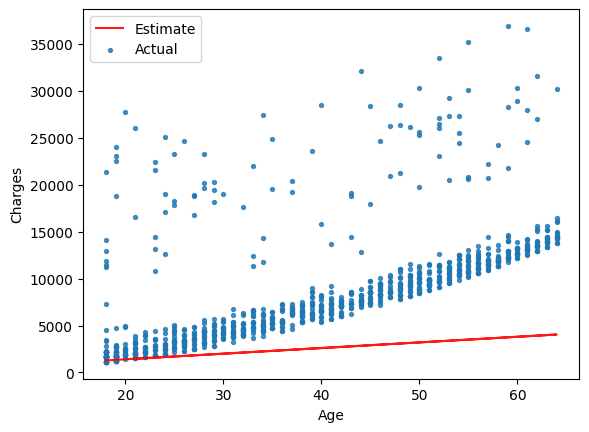

In [15]:
try_parameters(60, 200)

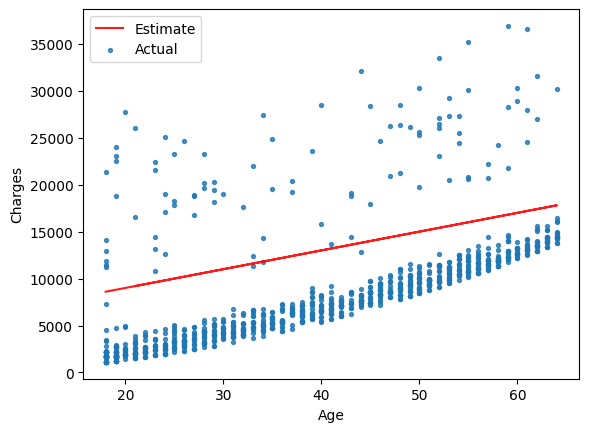

In [16]:
try_parameters(200, 5000)

> **ВПРАВА 1**: Спробуйте різні значення $w$ та $b$, щоб знайти лінію, яка найкраще підходить для даних. Який ефект від зміни значення $w$? Який ефект від зміни $b$?

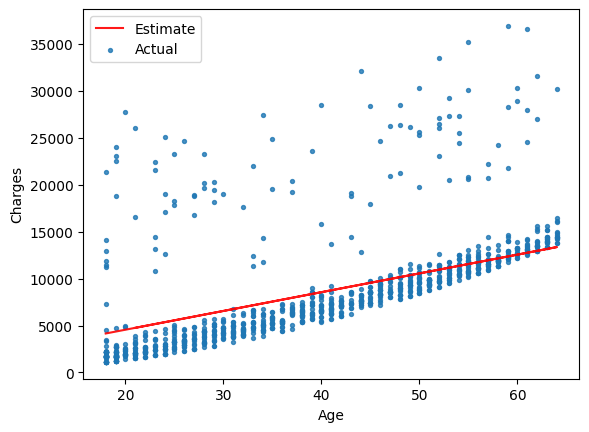

In [17]:
try_parameters(200, 550)

Коли ми змінюємо значення $w$ та $b$ вручну, намагаючись візуально наблизити лінію до точок, ми _вчимося_ приблизному відношенню між "віком" та "витратами".

Чи не було б чудово, якби комп'ютер міг спробувати кілька різних значень `w` та `b` та _вивчити_ відношення між "віком" та "витратами"? Щоб зробити це, нам потрібно вирішити кілька проблем:

1. Нам потрібен спосіб чисельно виміряти, наскільки добре лінія підходить до точок.

2. Після того, як "міра відповідності" була обчислена, нам потрібен спосіб змінити `w` та `b`, щоб покращити відповідність.

Якщо ми зможемо вирішити вищезазначені проблеми, комп'ютер повинен мати змогу визначити `w` та `b` для лінії найкращого відповідності, починаючи з випадкового припущення. Автоматичне визначення параметрів моделі за даними і зазначеними правилами і називається "машинним навчанням".

### Функція втрат/вартості

Ми можемо порівняти прогнози нашої моделі з фактичними цілями за допомогою наступного методу:

* Розрахувати різницю між цілями та прогнозами (ця різниця називається "залишком" - residual)
* Піднести до квадрату всі елементи матриці різниць, щоб усунути від'ємні значення.
* Розрахувати середнє значення елементів у результуючій матриці.
* Взяти квадратний корінь з результату

Результатом є одне число, відоме як **коренева середньоквадратична помилка** (RMSE - root mean squared error). Вищенаведений опис можна виразити математично наступним чином:

<img src="https://i.imgur.com/WCanPkA.png" width="360">

Геометрично, залишки можна візуалізувати наступним чином:

<img src="https://i.imgur.com/ll3NL80.png" width="420">

Давайте визначимо функцію для обчислення RMSE.

In [18]:
!pip install numpy --quiet

In [19]:
import numpy as np

In [20]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

Давайте обчислимо RMSE для нашої моделі з набором вибіркових ваг

In [21]:
w = 50
b = 100

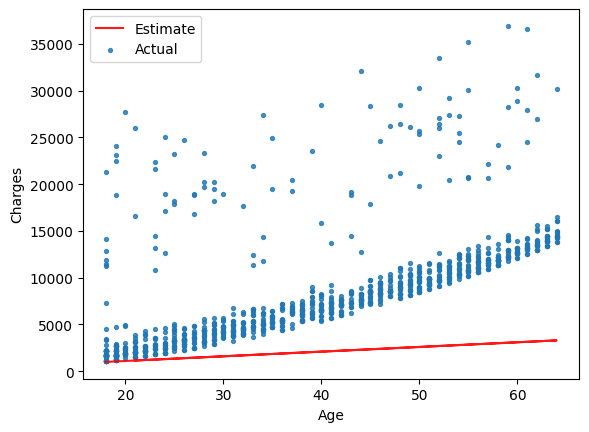

In [22]:
try_parameters(w, b)

In [23]:
targets = non_smoker_df['charges']
predicted = estimate_charges(non_smoker_df.age, w, b)

In [24]:
rmse(targets, predicted)

np.float64(8461.949562575493)

Ось як ми можемо інтерпретувати вищезазначене число: *В середньому, кожен елемент у прогнозі відрізняється від фактичної цілі на \$8461*.

Результат називається *втратою*, оскільки він вказує на те, наскільки погано модель прогнозує цільові змінні. Він представляє втрату інформації в моделі: чим нижче втрата, тим краща модель.

Давайте оновимо функцію `try_parameters`, щоб також відображати втрату.

In [25]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges
    predictions = estimate_charges(ages, w, b)

    plt.plot(ages, predictions, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8, alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual']);

    loss = rmse(target, predictions)
    print("RMSE Loss: ", loss)

RMSE Loss:  8461.949562575493


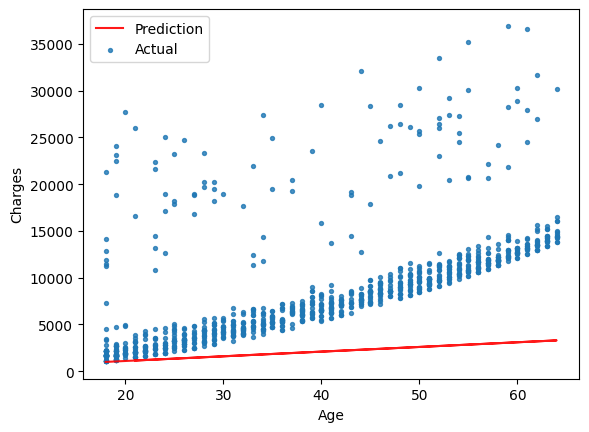

In [26]:
try_parameters(50, 100)

> **ВПРАВА 2**: Спробуйте різні значення $w$ та $b$, щоб мінімізувати втрати RMSE. Яке найнижче значення втрат ви зможете досягти? Опишіть як би ви таким методом спроб і помилок шукали найкращі значення $w$ та $b$?

Мені вдалося досягти 4747.41 RMSE Loss це найнижче значення яке мені довелося досягти методом спроб і помилок.

RMSE Loss:  4747.410290787951


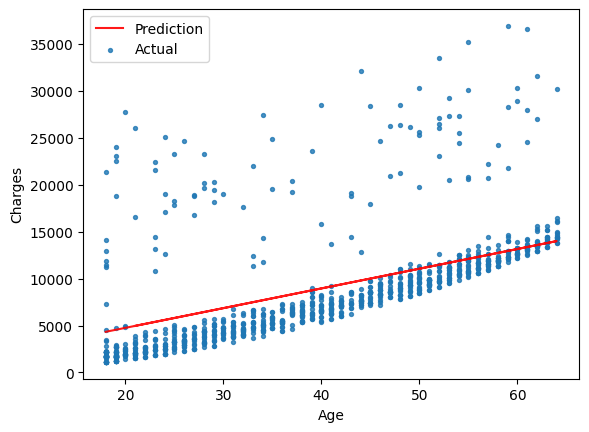

In [27]:
try_parameters(210, 550)

### Оптимізатор

Далі нам потрібна стратегія зміни ваг `w` та `b` для зменшення втрат і поліпшення "підгонки" лінії до даних.

* Метод найменших квадратів: https://www.youtube.com/watch?v=szXbuO3bVRk (краще для менших наборів даних)
* Стохастичний градієнтний спуск: https://www.youtube.com/watch?v=sDv4f4s2SB8 (краще для більших наборів даних)

Обидва ці методи мають однакову мету: мінімізувати втрати, однак, метод найменших квадратів безпосередньо обчислює найкращі значення для `w` та `b`, використовуючи операції з матрицями, тоді як градієнтний спуск використовує ітеративний підхід, починаючи з випадкових значень `w` та `b` і поступово поліпшуючи їх за допомогою похідних.

Ось візуалізація того, як працює градієнтний спуск:

![](https://miro.medium.com/max/1728/1*NO-YvpHHadk5lLxtg4Gfrw.gif)

Чи не схоже це на нашу власну стратегію поступового наближення лінії до точок?

### Лінійна регресія за допомогою Scikit-learn

На практиці вам ніколи не доведеться самостійно реалізовувати жоден з вищезазначених методів. Ви можете використовувати бібліотеку, таку як `scikit-learn`, щоб зробити це за вас.

In [28]:
!pip install scikit-learn --quiet

Давайте використовуємо клас `LinearRegression` з `scikit-learn`, щоб знайти найкращу лінію для `age` проти `charges` за допомогою методу Ordinary Least Squares.

In [29]:
from sklearn.linear_model import LinearRegression

Спочатку ми створюємо новий об'єкт моделі.

In [30]:
model = LinearRegression()

Далі ми можемо використати метод `fit` моделі, щоб знайти найкращу лінію, що відповідає вхідним даним та цілям.

In [31]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



Зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку.

In [32]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape :', inputs.shape)
print('targes.shape :', targets.shape)

inputs.shape : (1064, 1)
targes.shape : (1064,)


Давайте налаштуємо модель під дані.

In [33]:
model.fit(inputs, targets)

LinearRegression()

Ми можемо робити прогнози за допомогою моделі. Спробуймо прогнозувати витрати для віків 23, 37 та 61.

In [34]:
model.predict(np.array([[23],
                        [37],
                        [61]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 4055.30443855,  7796.78921819, 14210.76312614])

Чи здаються вам ці значення розумними? Порівняйте їх з діаграмою розсіювання вище.

Давайте обчислимо прогнози для всього набору вхідних даних.

In [35]:
predictions = model.predict(inputs)

In [36]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

Давайте обчислимо втрату RMSE для оцінки моделі.

In [37]:
rmse(targets, predictions)

np.float64(4662.505766636395)

Схоже, що наш прогноз відрізняється на $4000 в середньому, що не є занадто поганим, враховуючи те, що є декілька викидів.

Параметри моделі зберігаються в властивостях `coef_` та `intercept_`.

In [38]:
# w
model.coef_

array([267.24891283])

In [39]:
# b
model.intercept_

np.float64(-2091.4205565650864)

Чи є ці параметри близькими до ваших найкращих припущень?

Давайте візуалізуємо лінію, створену за допомогою вищезазначених параметрів.

RMSE Loss:  4662.505766636395


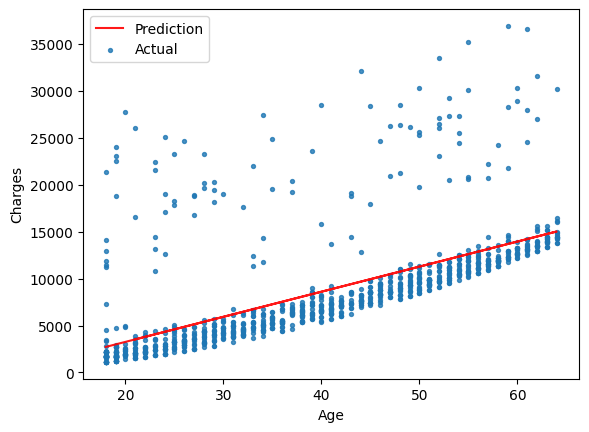

In [40]:
try_parameters(model.coef_, model.intercept_)

Справді, лінія досить близько до точок. Вона трохи вище за кластер точок, тому що вона також намагається врахувати викиди.

> **ВПРАВА 3**: Використовуйте клас [`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html) з `scikit-learn` для тренування моделі за допомогою техніки стохастичного градієнтного спуску. Зробіть прогнози та обчисліть втрати. Бачите якісь відмінності в результаті?

In [41]:
from sklearn.model_selection import train_test_split

# Крок 1: Визначаємо X (age) і y (charges)
X = medical_df[['age']]
y = medical_df['charges']

# Крок 2: Розділяємо на тренувальну і тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# Крок 1: Масштабування даних (ОБОВ'ЯЗКОВО для SGD!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Крок 2: Створення і тренування моделі
sgd_model = SGDRegressor(max_iter=1000, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

# Крок 3: Прогнози
predictions = sgd_model.predict(X_test_scaled)

# Крок 4: Обчислення втрат
loss = mean_absolute_error(y_test, predictions)
print(f"MAE (SGD): {loss:.2f}")

MAE (SGD): 9127.60


> **ВПРАВА 4**: Повторіть кроки цього розділу, щоб навчити модель лінійної регресії оцінювати `charges` для курців. Візуалізуйте цільові значення та прогнози, та обчисліть втрати.

In [43]:
# Залишаємо тільки курців
smoker_df = medical_df[medical_df['smoker'] == 'yes']

# Обираємо ознаку і ціль (для початку — тільки age)
X = smoker_df[['age']]
y = smoker_df['charges']

# Розділяємо на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Створюємо модель
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

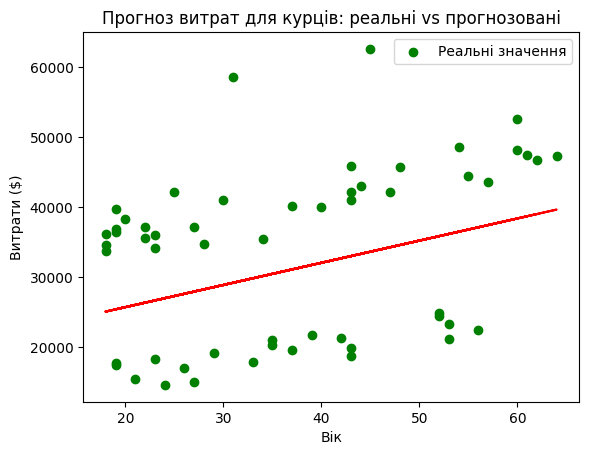

In [44]:
# Візуалізуємо значення і прогнози
plt.scatter(X_test, y_test, color='green', label='Реальні значення')
plt.plot(X_test, predictions, color='red')
plt.xlabel('Вік')
plt.ylabel('Витрати ($)')
plt.title('Прогноз витрат для курців: реальні vs прогнозовані')
plt.legend()
plt.show()

In [45]:
# Обчислюємо втрати
mae = mean_absolute_error(y_test, predictions)
print(f"MAE: {mae:.2f}")

MAE: 11068.73


### Машинне навчання

Вітаємо, ви щойно навчили свою першу _модель машинного навчання!_ Машинне навчання - це просто процес обчислення найкращих параметрів для моделювання взаємозвʼязку між деякою ознакою та цілями.

Кожна проблема машинного навчання має три компоненти:

1. **Модель**

2. **Функція втрат (Cost/Loss function)**

3. **Оптимізатор**


<img src="https://i.imgur.com/oiGQFJ9.png" width="480">

Як ми бачили вище, для тренування моделі машинного навчання за допомогою `scikit-learn` потрібно всього кілька рядків коду.

In [46]:
# Створюємо колонки незалежних змінних і цільової
inputs, targets = non_smoker_df[['age']], non_smoker_df['charges']

# Створюємо та тренуємо модель
model = LinearRegression().fit(inputs, targets)

# Генеруємо передбачення на основі вхідних даних (незалежних змінних)
predictions = model.predict(inputs)

# Обчислюємо втрати аби зрозуміти якість моделі
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.505766636395


## Лінійна регресія з використанням кількох характеристик

До цього моменту ми використовували лише характеристику "вік" для оцінки "витрат". Додавання іншої характеристики, наприклад "індекс маси тіла", є досить простим. Ми просто припускаємо наступну залежність:

$charges = w_1 \times age + w_2 \times bmi + b$

Нам потрібно змінити лише один рядок коду, щоб включити індекс маси тіла.

In [47]:
# Створюємо колонки незалежних змінних і цільової
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']

# Створюємо та тренуємо модель
model = LinearRegression().fit(inputs, targets)

# Генеруємо передбачення на основі вхідних даних (незалежних змінних)
predictions = model.predict(inputs)

# Обчислюємо втрати аби зрозуміти якість моделі
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.3128354612945


Як ви можете бачити, з додаванням ІМТ не вдається значно зменшити втрати, оскільки ІМТ має дуже слабку кореляцію з витратами, особливо для некурців.

In [48]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

In [49]:
fig = px.scatter(non_smoker_df, x='bmi', y='charges', title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

Ми також можемо візуалізувати взаємозв'язок між усіма трьома змінними "вік", "індекс маси тіла" та "витрати" за допомогою 3D діаграми розсіювання.

In [50]:
fig = px.scatter_3d(non_smoker_df, x='age', y='bmi', z='charges')
fig.update_traces(marker_size=3, marker_opacity=0.5)
fig.show()

Ви можете побачити, що інтерпретувати 3D діаграму розсіювання складніше, ніж 2D діаграму розсіювання. Як тільки ми додаємо більше характеристик, стає неможливим візуалізувати всі характеристики одночасно, через що ми використовуємо такі міри, як кореляція та втрати.

Також давайте перевіримо параметри моделі.

In [51]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

In [52]:
non_smoker_df[['age', 'bmi']].describe()

,age,bmi
count,1064.000000,1064.000000
mean,39.385338,30.651795
std,14.083410,6.043111
min,18.000000,15.960000
25%,26.750000,26.315000
50%,40.000000,30.352500
75%,52.000000,34.430000
max,64.000000,53.130000


Очевидно, ІМТ має набагато меншу вагу, і ви можете бачити чому. Він робить невеликий внесок, і навіть це, швидше за все, випадково. Це важливо мати на увазі: **ви не зможете знайти зв'язок, якого не існує, незалежно від того, яку техніку машинного навчання або алгоритм оптимізації ви застосовуєте.**

> **ВПРАВА 5**: Навчіть модель лінійної регресії оцінювати витрати, використовуючи лише BMI. Чи очікуєте ви, що вона буде кращою або гіршою за раніше навчені моделі?

In [53]:
# Створюємо колонки незалежних змінних і цільової
inputs, targets = non_smoker_df[['bmi']], non_smoker_df['charges']

# Створюємо та тренуємо модель
model = LinearRegression().fit(inputs, targets)

# Генеруємо передбачення на основі вхідних даних (незалежних змінних)
predictions = model.predict(inputs)

# Обчислюємо втрати аби зрозуміти якість моделі
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 5969.772531913293


Гіпотеза підтвердилась, модель виявилась гіршою використовуючи лише BMI 4662.31 vs 5969.77 BMI має набагато меншу вагу в порівнянні з іншими показниками.

Давайте зробимо ще один крок вперед і додамо останню числову колонку: "діти", яка, здається, має деяку кореляцію з "витратами".

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + b$

In [54]:
non_smoker_df.charges.corr(non_smoker_df.children)

np.float64(0.13892870453542192)

In [55]:
fig = px.strip(non_smoker_df, x='children', y='charges', title= "Children vs. Charges")
fig.update_traces(marker_size=4, marker_opacity=0.7)
fig.show()

In [56]:
# Створюємо колонки незалежних змінних і цільової
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']

# Створюємо та тренуємо модель
model = LinearRegression().fit(inputs, targets)

# Генеруємо передбачення на основі вхідних даних (незалежних змінних)
predictions = model.predict(inputs)

# Обчислюємо втрати аби зрозуміти якість моделі
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4608.470405038247


Ще раз, ми не бачимо великого зменшення втрат, хоча воно більше, ніж у випадку з ІМТ.

> **ВПРАВА 6**: Повторіть кроки цього підрозділу (створення моделей прогнозування на кількох характеристиках), щоб навчити модель лінійної регресії оцінювати медичні витрати для курців. Візуалізуйте цільові значення та прогнози, та обчисліть loss.

In [57]:
smoker_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92400
11,62,female,26.29,0,yes,southeast,27808.72510
14,27,male,42.13,0,yes,southeast,39611.75770
19,30,male,35.30,0,yes,southwest,36837.46700
23,34,female,31.92,1,yes,northeast,37701.87680
29,31,male,36.30,2,yes,southwest,38711.00000
30,22,male,35.60,0,yes,southwest,35585.57600
34,28,male,36.40,1,yes,southwest,51194.55914
38,35,male,36.67,1,yes,northeast,39774.27630
39,60,male,39.90,0,yes,southwest,48173.36100


In [58]:
smoker_df.describe().round(2)

,age,bmi,children,charges
count,274.00,274.00,274.00,274.00
mean,38.51,30.71,1.11,32050.23
std,13.92,6.32,1.16,11541.55
min,18.00,17.20,0.00,12829.46
25%,27.00,26.08,0.00,20826.24
50%,38.00,30.45,1.00,34456.35
75%,49.00,35.20,2.00,41019.21
max,64.00,52.58,5.00,63770.43


In [59]:
# Створюємо колонки незалежних змінних і цільової
inputs, targets = smoker_df[['age', 'bmi', 'children']], smoker_df['charges']

# Створюємо та тренуємо модель
model = LinearRegression().fit(inputs, targets)

# Генеруємо передбачення на основі вхідних даних (незалежних змінних)
predictions = model.predict(inputs)

# Обчислюємо втрати аби зрозуміти якість моделі
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 5718.202480524154


In [60]:
fig = px.scatter_3d(smoker_df, x='age', y='bmi', z='charges')
fig.update_traces(marker_size=3, marker_opacity=0.5)
fig.show()

> **ВПРАВА 7**: Повторіть кроки цього підрозділу, щоб навчити модель лінійної регресії оцінювати медичні витрати для всіх клієнтів. Візуалізуйте цілі та прогнози, та обчисліть loss. Чи втрати нижчі чи вищі?

In [61]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [62]:
# Створюємо колонки незалежних змінних і цільової
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df['charges']

# Створюємо та тренуємо модель
model = LinearRegression().fit(inputs, targets)

# Генеруємо передбачення на основі вхідних даних (незалежних змінних)
predictions = model.predict(inputs)

# Обчислюємо втрати аби зрозуміти якість моделі
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


In [63]:
fig = px.scatter_3d(medical_df, x='age', y='bmi', z='charges')
fig.update_traces(marker_size=3, marker_opacity=0.5)
fig.show()

Розділення клієнтів на курців і некурців суттєво покращує точність прогнозу. Коли ми будуємо єдину модель для всіх клієнтів разом, вона намагається усереднити два різні патерни витрат — некурці мають низькі та стабільні витрати, а курці — значно вищі та більш розкидані. Це змушує модель робити компроміс, який погано підходить для обох груп одночасно: MAE = $11,355.     
Окремі моделі для курців MAE = $5,718 і некурців MAE = $4,608 точніші, бо кожна модель навчається на однорідніших даних зі схожими закономірностями.

## Використання категоріальних ознак для машинного навчання

До цього моменту ми використовували лише числові стовпці, оскільки ми можемо виконувати обчислення лише з числами. Якщо б ми могли використовувати категоріальні стовпці, як "курець", ми могли б навчити єдину модель для всього набору даних.

Щоб використовувати категоріальні стовпці, нам просто потрібно перетворити їх на числа. Існує три поширені техніки для цього:

1. Якщо категоріальний стовпець має лише дві категорії (його називають бінарною категорією), то ми можемо замінити їх значення на 0 і 1.
2. Якщо категоріальний стовпець має більше ніж 2 категорії, ми можемо виконати [one-hot кодування](https://www.geeksforgeeks.org/ml-one-hot-encoding/), тобто створити новий стовпець для кожної категорії з 1 та 0.
3. Якщо категорії мають природний порядок (наприклад, холодно, нейтрально, тепло, гаряче), то вони можуть бути перетворені на числа (наприклад, 1, 2, 3, 4), зберігаючи порядок. Таке кодування називається ordinal encoding.

In [64]:
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


## Бінарні категорії

Категорія "курець" має лише два значення "так" та "ні". Створимо нову колонку "smoker_code", де 0 відповідає "ні", а 1 - "так".

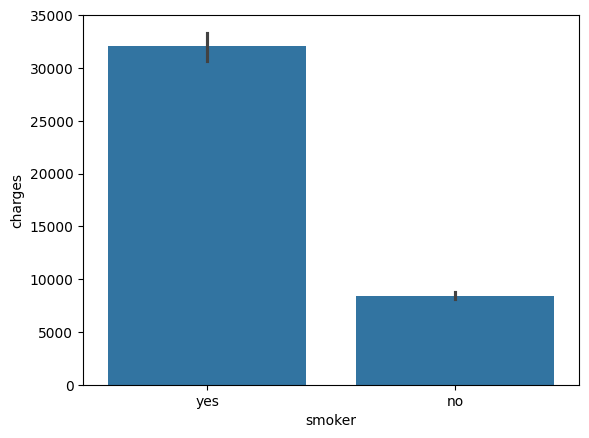

In [65]:
sns.barplot(data=medical_df, x='smoker', y='charges');

In [66]:
smoker_codes = {'no': 0, 'yes': 1}
medical_df['smoker_code'] = medical_df.smoker.map(smoker_codes)

In [67]:
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.787251430498478)

Тепер ми можемо використовувати стовпець `smoker_df` для лінійної регресії.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + b$

In [68]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.439217188081


Втрати зменшилися з `11355` до `6056`, майже на 50%! Це важливий урок: ніколи не ігноруйте категоріальні дані.

Спробуємо додати стовпець "стать".

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + b$

<Axes: xlabel='sex', ylabel='charges'>

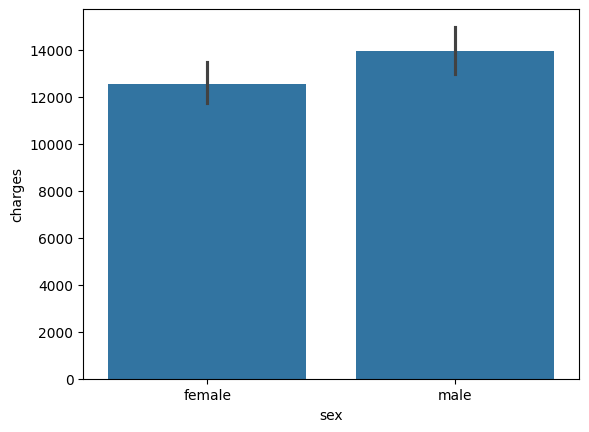

In [69]:
sns.barplot(data=medical_df, x='sex', y='charges')

In [70]:
sex_codes = {'female': 0, 'male': 1}

In [71]:
medical_df['sex_code'] = medical_df.sex.map(sex_codes)

In [72]:
medical_df.charges.corr(medical_df.sex_code)

np.float64(0.057292062202025484)

In [73]:
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df['charges']

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6056.100708754546


Ця колонка не надто повпливала на модель.

### One-hot кодування

Стовпець "region" містить 4 значення, тому нам потрібно використовувати one-hot encoding та створити новий стовпець для кожного регіону.

![](https://i.imgur.com/n8GuiOO.png)

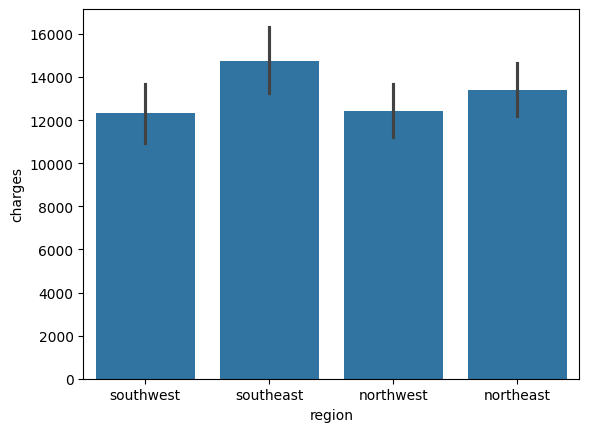

In [74]:
sns.barplot(data=medical_df, x='region', y='charges');

In [75]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [76]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [77]:
medical_df[enc.categories_[0]] = one_hot

In [78]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


Давайте включимо стовпці регіону до нашої моделі лінійної регресії.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

In [79]:
# Створюємо колонки незалежних змінних і цільової
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

# Створюємо та тренуємо модель
model = LinearRegression().fit(inputs, targets)

# Генеруємо передбачення на основі вхідних даних (незалежних змінних)
predictions = model.predict(inputs)

# Обчислюємо втрати аби зрозуміти якість моделі
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


Ще раз, це призводить до досить невеликого зменшення втрат.

> **ВПРАВА 8**: Чи дві окремі моделі лінійної регресії, одна для курців і одна для некурців, кращі, ніж одна модель лінійної регресії? Чому на ваш погляд так або ні? Спробуйте це і подивіться, чи можете ви обгрунтувати свою відповідь даними.

In [88]:
# створюємо нову колонку для не курців по статі де жінки будуть - 0 а чоловіки - 1
sex_codesns = {'female': 0, 'male': 1}

In [89]:
non_smoker_df['sex_codesns'] = non_smoker_df.sex.map(sex_codesns)

/tmp/ipykernel_676/2308714827.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [90]:
non_smoker_df.charges.corr(non_smoker_df.sex_codesns)

np.float64(-0.056320160724481594)

In [91]:
non_smoker_df

,age,sex,bmi,children,smoker,region,charges,northeast,northwest,southeast,southwest,sex_codesns
1,18,male,33.770,1,no,southeast,1725.55230,0.0,0.0,1.0,0.0,1
2,28,male,33.000,3,no,southeast,4449.46200,0.0,0.0,1.0,0.0,1
3,33,male,22.705,0,no,northwest,21984.47061,0.0,1.0,0.0,0.0,1
4,32,male,28.880,0,no,northwest,3866.85520,0.0,1.0,0.0,0.0,1
5,31,female,25.740,0,no,southeast,3756.62160,0.0,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500,0.0,0.0,0.0,1.0,0
1333,50,male,30.970,3,no,northwest,10600.54830,0.0,1.0,0.0,0.0,1
1334,18,female,31.920,0,no,northeast,2205.98080,1.0,0.0,0.0,0.0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0.0,0.0,1.0,0.0,0


In [83]:
enc = preprocessing.OneHotEncoder()
enc.fit(non_smoker_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [84]:
one_hot = enc.transform(non_smoker_df[['region']]).toarray()
one_hot

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       ...,
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [86]:
non_smoker_df[enc.categories_[0]] = one_hot
non_smoker_df

/tmp/ipykernel_676/3479091351.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,age,sex,bmi,children,smoker,region,charges,northeast,northwest,southeast,southwest
1,18,male,33.770,1,no,southeast,1725.55230,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0.0,1.0,0.0,0.0
5,31,female,25.740,0,no,southeast,3756.62160,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500,0.0,0.0,0.0,1.0
1333,50,male,30.970,3,no,northwest,10600.54830,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0.0,0.0,1.0,0.0


In [92]:
# Створюємо колонки незалежних змінних і цільової
input_cols = ['age', 'bmi', 'children', 'sex_codesns', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = non_smoker_df[input_cols], non_smoker_df['charges']

# Створюємо та тренуємо модель
model = LinearRegression().fit(inputs, targets)

# Генеруємо передбачення на основі вхідних даних (незалежних змінних)
predictions = model.predict(inputs)

# Обчислюємо втрати аби зрозуміти якість моделі
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4573.074988795492


In [93]:
# створюємо нову колонку для курців по статі де жінки будуть - 0 а чоловіки - 1
sex_codess = {'female': 0, 'male': 1}

In [94]:
smoker_df['sex_codess'] = smoker_df.sex.map(sex_codess)

/tmp/ipykernel_676/1135095801.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [95]:
smoker_df.charges.corr(smoker_df.sex_codess)

np.float64(0.10122606403569742)

In [96]:
smoker_df

,age,sex,bmi,children,smoker,region,charges,sex_codess
0,19,female,27.900,0,yes,southwest,16884.92400,0
11,62,female,26.290,0,yes,southeast,27808.72510,0
14,27,male,42.130,0,yes,southeast,39611.75770,1
19,30,male,35.300,0,yes,southwest,36837.46700,1
23,34,female,31.920,1,yes,northeast,37701.87680,0
...,...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600,0
1314,30,female,23.655,3,yes,northwest,18765.87545,0
1321,62,male,26.695,0,yes,northeast,28101.33305,1
1323,42,female,40.370,2,yes,southeast,43896.37630,0


In [97]:
enc = preprocessing.OneHotEncoder()
enc.fit(smoker_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [98]:
one_hot = enc.transform(smoker_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.]])

In [99]:
smoker_df[enc.categories_[0]] = one_hot
smoker_df

/tmp/ipykernel_676/1082605530.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_676/1082605530.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_676/1082605530.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_676/108

,age,sex,bmi,children,smoker,region,charges,sex_codess,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,0,0.0,0.0,0.0,1.0
11,62,female,26.290,0,yes,southeast,27808.72510,0,0.0,0.0,1.0,0.0
14,27,male,42.130,0,yes,southeast,39611.75770,1,0.0,0.0,1.0,0.0
19,30,male,35.300,0,yes,southwest,36837.46700,1,0.0,0.0,0.0,1.0
23,34,female,31.920,1,yes,northeast,37701.87680,0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600,0,0.0,0.0,0.0,1.0
1314,30,female,23.655,3,yes,northwest,18765.87545,0,0.0,1.0,0.0,0.0
1321,62,male,26.695,0,yes,northeast,28101.33305,1,1.0,0.0,0.0,0.0
1323,42,female,40.370,2,yes,southeast,43896.37630,0,0.0,0.0,1.0,0.0


In [100]:
# Створюємо колонки незалежних змінних і цільової
input_cols = ['age', 'bmi', 'children', 'sex_codess', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = smoker_df[input_cols], smoker_df['charges']

# Створюємо та тренуємо модель
model = LinearRegression().fit(inputs, targets)

# Генеруємо передбачення на основі вхідних даних (незалежних змінних)
predictions = model.predict(inputs)

# Обчислюємо втрати аби зрозуміти якість моделі
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 5668.4678821121515


Розділювати моделі на курців і не курців є сенс щоб знайти більш впливові показники для точнішої моделі. Окремі моделі лінійної регресії краще по показнику витрат тому що дані більш чутливіші на мій погляд до окремого показника.
Для курців показник втрат: 5668.46
для не курців: 4573.07
Модель для курців і для не курців разом: 6041.67

## Удосконалення моделі

Давайте обговоримо та застосуємо деякі додаткові удосконалення нашої моделі.

### Масштабування ознак

Пам'ятайте, що через регулятивні вимоги в задачі, нам також потрібно навести обґрунтування прогнозів нашої моделі.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

Щоб порівняти важливість кожної ознаки в моделі, наш перший імпульс може бути порівнянням їх ваг.

In [101]:
model.coef_

array([  267.40438625,  1475.54562981,   182.73655059,  -388.1216487 ,
         754.5850207 ,    64.86699592, -1138.15349664,   318.70148002])

In [102]:
model.intercept_

np.float64(-23426.354338758963)

In [103]:
weights_df = pd.DataFrame({
    'feature': np.append(input_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df

,feature,weight
0,age,267.404386
1,bmi,1475.545630
2,children,182.736551
3,sex_codess,-388.121649
4,northeast,754.585021
5,northwest,64.866996
6,southeast,-1138.153497
7,southwest,318.701480
8,1,-23426.354339


Хоча здається, що BMI та northeast мають вищу вагу, ніж вік, майте на увазі, що діапазон значень для BMI обмежений (від 15 до 40), а стовпець northeast приймає лише значення 0 та 1.

Оскільки різні стовпці мають різні діапазони, ми стикаємося з двома проблемами:

1. Ми не можемо порівняти ваги різних стовпців, щоб визначити, які ознаки є важливими
2. Стовпець з більшим діапазоном вхідних даних може непропорційно впливати на втрати та домінувати в процесі оптимізації.

З цієї причини звичайною практикою є масштабування (або стандартизація) значень в числовому стовпці шляхом віднімання середнього значення та ділення на стандартне відхилення.


**Стандартизація (масштабування):**

$$
z = \frac{x - \mu}{\sigma}
$$

де

* **середнє значення (mean):**

$$
\mu = \frac{1}{N} \sum_{i=1}^{N} x_i
$$

* **стандартне відхилення (standard deviation):**

$$
\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}
$$

Ми можемо застосувати масштабування за допомогою класу StandardScaler з `scikit-learn`.

In [104]:
from sklearn.preprocessing import StandardScaler

In [105]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])

StandardScaler()

In [106]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [107]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

Ми можемо масштабувати дані наступним чином:

In [108]:
scaled_inputs = scaler.transform(medical_df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

Ці дані тепер можна поєднати з категоріальними даними.

In [109]:
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values

In [110]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = medical_df.charges

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


Ми тепер можемо порівняти ваги в формулі:

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

In [111]:
weights_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending=False).style.background_gradient()

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


Як ви можете бачити зараз, найважливіші характеристики є:

1. Курець
2. Вік
3. Індекс маси тіла

### Створення тестового набору

Моделі, подібні до тієї, що ми створили в цьому розділі, призначені для використання **в реальному світі**. Зазвичай прийнято відкладати невелику частину даних (наприклад, 10%) лише для тестування та повідомлення про результати моделі.

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.1)

In [114]:
inputs_train.shape, inputs_test.shape

((1204, 9), (134, 9))

In [115]:
inputs_train

array([[-1.08275831, -0.12112993, -0.90861367, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.76847264, -0.66657783, -0.90861367, ...,  0.        ,
         0.        ,  1.        ],
       [-0.29954522, -0.5008929 , -0.07876719, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 1.48048454, -0.02680435, -0.90861367, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.7652893 ,  1.61035956, -0.90861367, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.41246669,  0.18481303, -0.90861367, ...,  0.        ,
         1.        ,  0.        ]])

In [116]:
# Create and train the model
model = LinearRegression().fit(inputs_train, targets_train)

# Generate predictions
predictions_test = model.predict(inputs_test)

# Compute loss to evalute the model
loss = rmse(targets_test, predictions_test)
print('Test Loss:', loss)

Test Loss: 6280.257096948712


Порівняймо це з втратами під час тренування.

In [117]:
# Generate predictions
predictions_train = model.predict(inputs_train)

# Compute loss to evalute the model
loss = rmse(targets_train, predictions_train)
print('Training Loss:', loss)

Training Loss: 6016.252767885241


Ми завжди аналізуємо різницю між втратами на тренувальному і тестувальному наборах даних, адже це нам каже про якість моделі і про те, чи справді вона навчилась передбачати на нових даних, яких раніше не бачила. Детальніше про це - [тут](https://www.geeksforgeeks.org/underfitting-and-overfitting-in-machine-learning/).

### Як підійти до проблеми машинного навчання

Ось стратегія, яку ви можете застосувати для підходу до будь-якої проблеми машинного навчання:

1. Дослідіть дані та знайдіть кореляції між вхідними даними та цілями
2. Виберіть правильну модель, функції втрат та оптимізатор для даної проблеми
3. Масштабуйте числові змінні та використовуйте one-hot кодування для категоріальних даних
4. Відкладіть тестовий набір (використовуючи частину навчального набору)
5. Навчіть модель
6. Зробіть прогнози на тестовому наборі та обчисліть втрати

Ми застосуємо цей процес до кількох проблем у наступних розділах.

## Підсумок

Ми розглянули наступні теми в цьому розіділі:

- Класичне формулювання проблеми для машинного навчання
- Завантаження та дослідження набору даних для машинного навчання
- Лінійна регресія з однією змінною за допомогою Scikit-learn
- Лінійна регресія з кількома ознаками
- Використання категоріальних ознак для машинного навчання
- Коефіцієнти регресії та важливість ознак
- Створення навчального та тестового наборів для виміру якості моделі

В якості додаткової практики, рекомендую застосувати техніки, розглянуті в цьому практичному занятті, до наступних наборів даних:

- https://www.kaggle.com/vikrishnan/boston-house-prices
- https://www.kaggle.com/sohier/calcofi
- https://www.kaggle.com/budincsevity/szeged-weather

## Питання для повторення

Дайте відповіді на наступні питання аби повторонити пройдене в першій темі.

1.	Чому ми повинні проводити EDA перед тим, як тренувати модель до даних?
2.	Що таке параметр?
3.	Що таке кореляція?
4.	Що означає негативна кореляція?
5.	Як можна знайти кореляцію між змінними в Python?
6.	Що таке каузальність? Поясніть різницю між кореляцією та каузальністю на прикладі.
7.	Визначте лінійну регресію.
8.	Що таке одновимірна лінійна регресія?
9.	Що таке багатовимірна лінійна регресія?
10.	Що таке ваги та зміщення?
11.	Що таке вхідні дані та цільові дані?
12.	Що таке функція втрат/вартості?
13.	Що таке залишок?
14.	Що таке значення RMSE? Коли і чому ми його використовуємо?
15.	Що таке оптимізатор? Які існують типи оптимізаторів? Поясніть кожен на прикладі.
16.	Яка бібліотека доступна в Python для виконання лінійної регресії?
17.	Що таке <code>sklearn.linear_model </code>?
18.	Що робить <code>model.fit()</code>? Які аргументи повинні бути надані?
19.	Що робить <code>model.predict()</code>? Які аргументи повинні бути надані?
20.	Як ми розраховуємо значення RMSE?
21.	Що таке <code>model.coef_</code>?
22.	Що таке <code>model.intercept_</code>?
23.	Що таке SGDRegressor? Чим він відрізняється від лінійної регресії?
24.	Визначте машинне навчання. Які основні компоненти в машинному навчанні?
25.	Як значення втрат допомагає визначити, чи є модель хорошою чи ні?
26.	Що таке неперервні та категоріальні змінні?
27.	Як ми обробляємо категоріальні змінні в машинному навчанні? Які є загальні методики?
28.	Що таке масштабування ознак? Як воно допомагає в машинному навчанні?
29.	Як ми виконуємо масштабування в Python?
30.	Що таке <code>sklearn.preprocessing</code>?
31.	Що таке тестовий набір даних?
32.	Як ми розбиваємо дані для підгонки моделі (навчання та тестування) в Python?
33.	Як ви будете підходити до проблеми машинного навчання?